In [1]:
import os, random, copy
import numpy as np, pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_DIR = "/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT"

train_csv = os.path.join(DATA_DIR, "train.csv")
val_csv   = os.path.join(DATA_DIR, "validation.csv")
test_csv  = os.path.join(DATA_DIR, "test.csv")

BATCH_SIZE = 32
EPOCHS = 30
SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

print("DEVICE:", DEVICE)

DEVICE: cuda


In [4]:
class EuroSATDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.df = pd.read_csv(csv_file)

        if self.df.columns[0] == "Unnamed: 0":
            self.df = self.df.drop(columns=self.df.columns[0])

        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(self.df["ClassName"].unique())
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.df.iloc[idx]["Filename"])
        label = self.class_to_idx[self.df.iloc[idx]["ClassName"]]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [5]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

In [6]:
train_dataset = EuroSATDataset(train_csv, DATA_DIR, train_transform)
val_dataset   = EuroSATDataset(val_csv,   DATA_DIR, val_transform)
test_dataset  = EuroSATDataset(test_csv,  DATA_DIR, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

num_classes = len(train_dataset.classes)

In [7]:
def create_model():
    model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

    for param in model.parameters():
        param.requires_grad = False

    for param in model.features[7].parameters():
        param.requires_grad = True

    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)

    return model.to(DEVICE)

In [8]:
def plot_history(history, title="Training Curve"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


In [9]:
def train_model(optimizer_name, lr):

    model = create_model()
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    elif optimizer_name == "AdamW":
        optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    elif optimizer_name == "SGD":
        optimizer = torch.optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, momentum=0.9)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=2)

    best_val_acc = 0
    best_model_wts = copy.deepcopy(model.state_dict())

    patience = 5
    no_improve = 0

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(EPOCHS):

        # TRAIN
        model.train()
        running_loss = 0
        train_preds, train_labels = [], []

        for images, labels in tqdm(train_loader):
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            preds = torch.argmax(outputs, 1).cpu().numpy()
            train_preds.extend(preds)
            train_labels.extend(labels.cpu().numpy())

        train_loss = running_loss / len(train_loader)
        train_acc = accuracy_score(train_labels, train_preds)

        # VALID
        model.eval()
        val_preds, val_labels = [], []
        val_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)

                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                preds = torch.argmax(outputs, 1).cpu().numpy()
                val_preds.extend(preds)
                val_labels.extend(labels.cpu().numpy())
                
        val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(val_labels, val_preds)

        print(f"{optimizer_name} | LR={lr} | Epoch {epoch+1} | Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f}")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        scheduler.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping")
                break

    model.load_state_dict(best_model_wts)

    return model, best_val_acc, history


In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model):

    model.eval()
    test_preds, test_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)

            outputs = model(images)
            preds = torch.argmax(outputs, 1).cpu().numpy()

            test_preds.extend(preds)
            test_labels.extend(labels.numpy())

    acc = accuracy_score(test_labels, test_preds)
    precision = precision_score(test_labels, test_preds, average='weighted')
    recall = recall_score(test_labels, test_preds, average='weighted')
    f1_macro = f1_score(test_labels, test_preds, average='macro')
    f1_weighted = f1_score(test_labels, test_preds, average='weighted')

    print("\n===== CLASSIFICATION REPORT =====")
    print(classification_report(test_labels, test_preds))

    print("\n===== CONFUSION MATRIX =====")
    cm = confusion_matrix(test_labels, test_preds)
    print(cm)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return {
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1_macro": f1_macro,
        "F1_weighted": f1_weighted
    }

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 197MB/s] 
100%|██████████| 591/591 [04:19<00:00,  2.28it/s]


Adam | LR=0.001 | Epoch 1 | Train Acc=0.9309 | Val Acc=0.9652


100%|██████████| 591/591 [02:34<00:00,  3.81it/s]


Adam | LR=0.001 | Epoch 2 | Train Acc=0.9635 | Val Acc=0.9687


...

Adam | LR=0.001 | Epoch 19 | Train Acc=0.9978 | Val Acc=0.9794


100%|██████████| 591/591 [02:35<00:00,  3.81it/s]


Adam | LR=0.001 | Epoch 20 | Train Acc=0.9975 | Val Acc=0.9807


100%|██████████| 591/591 [02:35<00:00,  3.81it/s]


Adam | LR=0.001 | Epoch 21 | Train Acc=0.9980 | Val Acc=0.9811
Early stopping


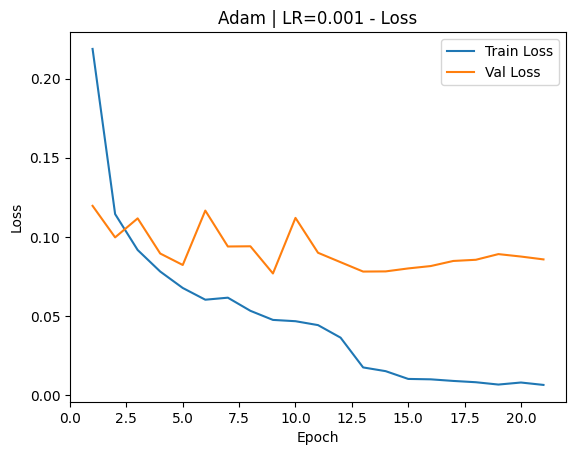

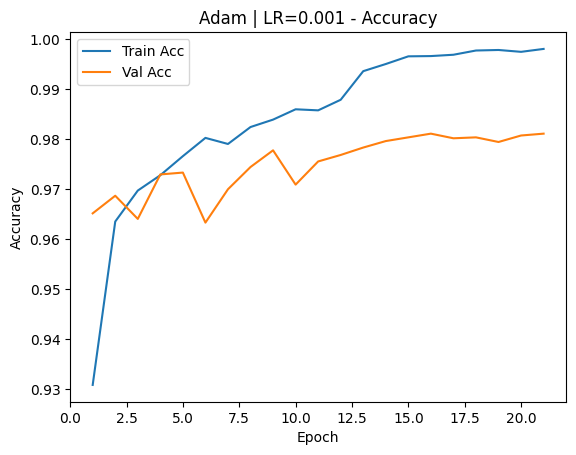

100%|██████████| 591/591 [02:35<00:00,  3.80it/s]


Adam | LR=0.0001 | Epoch 1 | Train Acc=0.9257 | Val Acc=0.9565


100%|██████████| 591/591 [02:35<00:00,  3.79it/s]


Adam | LR=0.0001 | Epoch 2 | Train Acc=0.9720 | Val Acc=0.9617


100%|██████████| 591/591 [02:35<00:00,  3.79it/s]


...

Adam | LR=0.0001 | Epoch 23 | Train Acc=0.9992 | Val Acc=0.9789


100%|██████████| 591/591 [02:42<00:00,  3.63it/s]


Adam | LR=0.0001 | Epoch 24 | Train Acc=0.9982 | Val Acc=0.9796


100%|██████████| 591/591 [02:51<00:00,  3.45it/s]


Adam | LR=0.0001 | Epoch 25 | Train Acc=0.9988 | Val Acc=0.9802
Early stopping


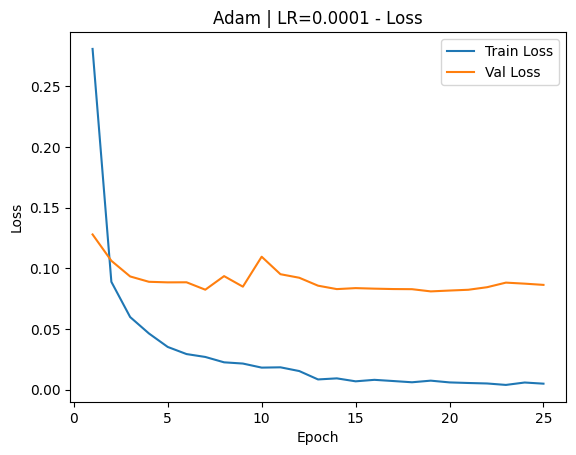

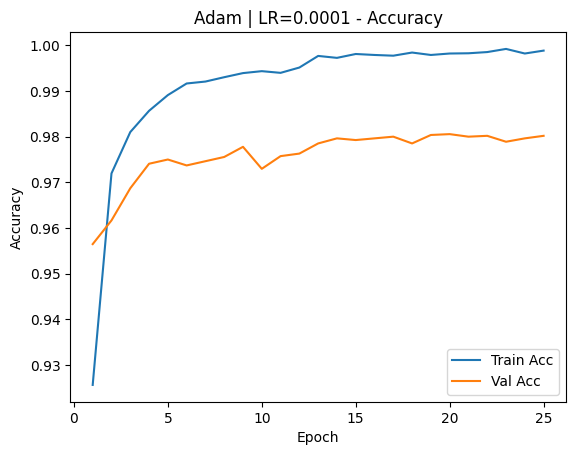

100%|██████████| 591/591 [02:36<00:00,  3.77it/s]


Adam | LR=1e-05 | Epoch 1 | Train Acc=0.7669 | Val Acc=0.9241


100%|██████████| 591/591 [02:39<00:00,  3.72it/s]


Adam | LR=1e-05 | Epoch 2 | Train Acc=0.9310 | Val Acc=0.9481


100%|██████████| 591/591 [02:35<00:00,  3.79it/s]


...

Adam | LR=1e-05 | Epoch 15 | Train Acc=0.9871 | Val Acc=0.9713


100%|██████████| 591/591 [02:38<00:00,  3.74it/s]


Adam | LR=1e-05 | Epoch 16 | Train Acc=0.9890 | Val Acc=0.9726


100%|██████████| 591/591 [02:36<00:00,  3.77it/s]


Adam | LR=1e-05 | Epoch 17 | Train Acc=0.9898 | Val Acc=0.9731
Early stopping


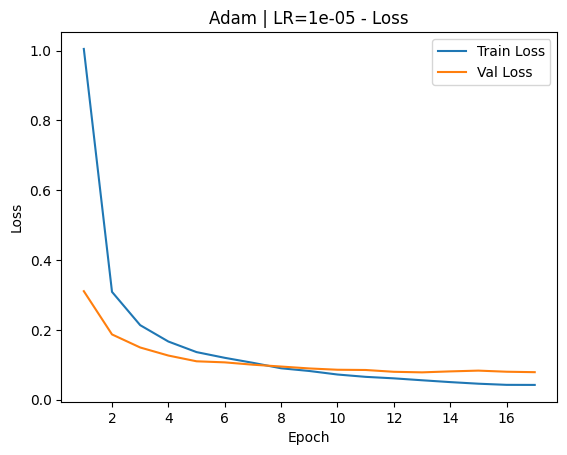

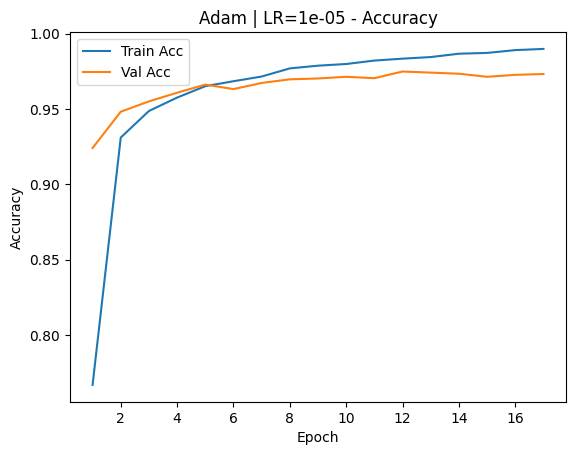


>>> BEST Adam: LR=0.001 | Val Acc=0.9811


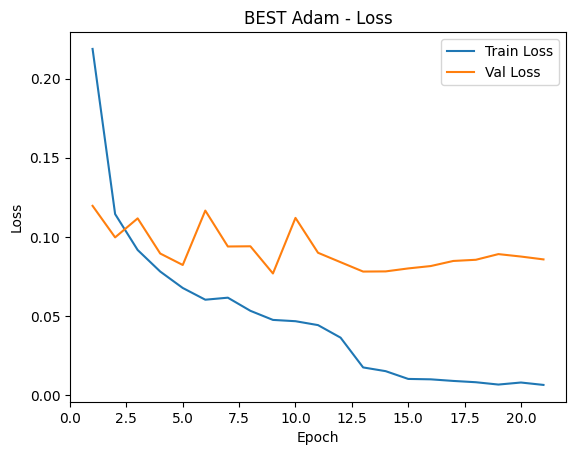

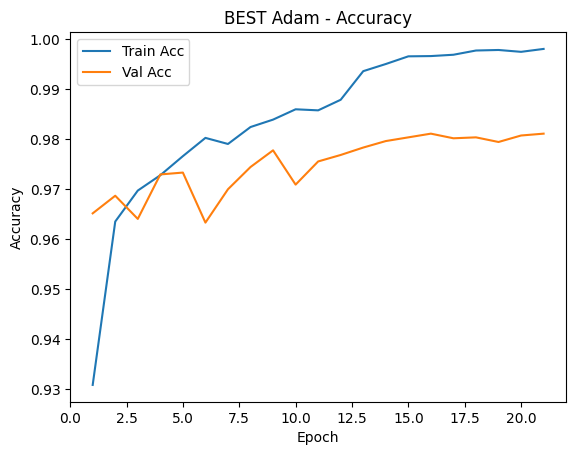


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       300
           1       0.99      0.99      0.99       300
           2       0.98      0.98      0.98       300
           3       0.97      0.99      0.98       250
           4       0.98      1.00      0.99       250
           5       0.98      0.97      0.98       200
           6       0.96      0.97      0.96       250
           7       1.00      1.00      1.00       300
           8       0.99      0.98      0.98       250
           9       1.00      1.00      1.00       300

    accuracy                           0.99      2700
   macro avg       0.98      0.99      0.98      2700
weighted avg       0.99      0.99      0.99      2700


===== CONFUSION MATRIX =====
[[291   0   0   1   0   1   7   0   0   0]
 [  0 298   1   0   0   0   0   0   1   0]
 [  0   2 294   1   0   2   1   0   0   0]
 [  0   0   0 247   1   0   0   0   2   0]
 [  

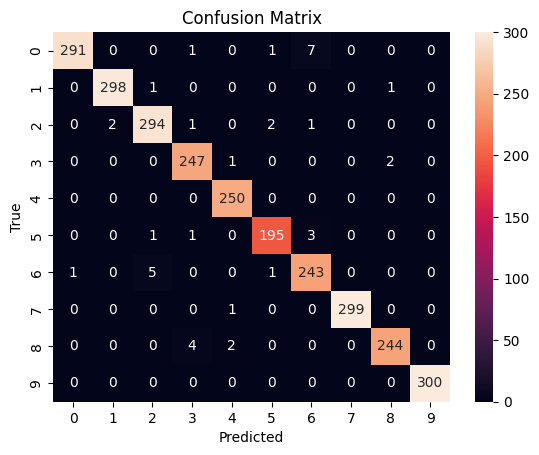

100%|██████████| 591/591 [02:35<00:00,  3.79it/s]


AdamW | LR=0.001 | Epoch 1 | Train Acc=0.9297 | Val Acc=0.9493


100%|██████████| 591/591 [02:36<00:00,  3.78it/s]


AdamW | LR=0.001 | Epoch 2 | Train Acc=0.9628 | Val Acc=0.9696


100%|██████████| 591/591 [02:34<00:00,  3.83it/s]


...

AdamW | LR=0.001 | Epoch 10 | Train Acc=0.9947 | Val Acc=0.9774


100%|██████████| 591/591 [02:33<00:00,  3.85it/s]


AdamW | LR=0.001 | Epoch 11 | Train Acc=0.9962 | Val Acc=0.9789


100%|██████████| 591/591 [02:35<00:00,  3.81it/s]


AdamW | LR=0.001 | Epoch 12 | Train Acc=0.9959 | Val Acc=0.9789
Early stopping


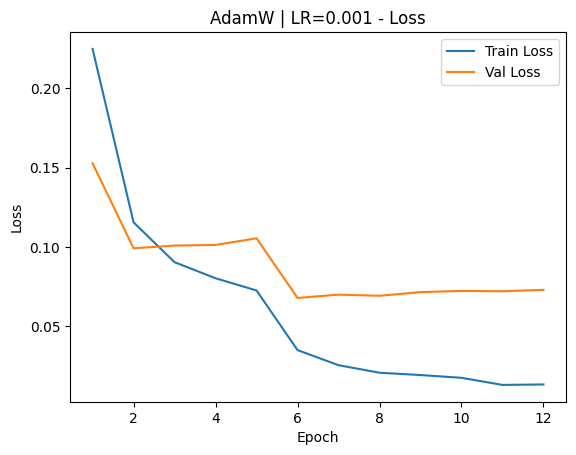

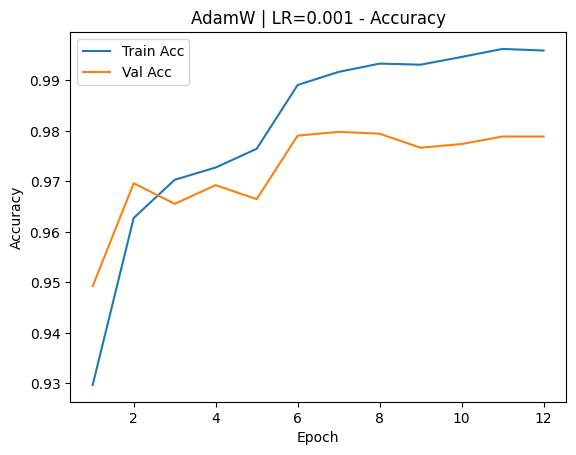

100%|██████████| 591/591 [02:35<00:00,  3.79it/s]


AdamW | LR=0.0001 | Epoch 1 | Train Acc=0.9235 | Val Acc=0.9628


100%|██████████| 591/591 [02:34<00:00,  3.82it/s]


AdamW | LR=0.0001 | Epoch 2 | Train Acc=0.9744 | Val Acc=0.9652


100%|██████████| 591/591 [02:34<00:00,  3.82it/s]


...

AdamW | LR=0.0001 | Epoch 18 | Train Acc=0.9981 | Val Acc=0.9785


100%|██████████| 591/591 [02:35<00:00,  3.79it/s]


AdamW | LR=0.0001 | Epoch 19 | Train Acc=0.9980 | Val Acc=0.9783


100%|██████████| 591/591 [02:34<00:00,  3.82it/s]


AdamW | LR=0.0001 | Epoch 20 | Train Acc=0.9983 | Val Acc=0.9780
Early stopping


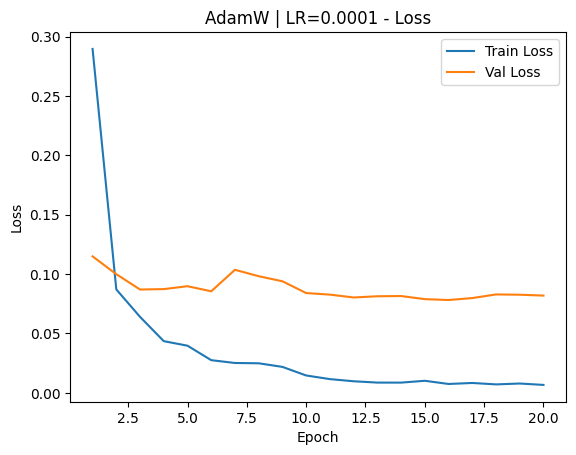

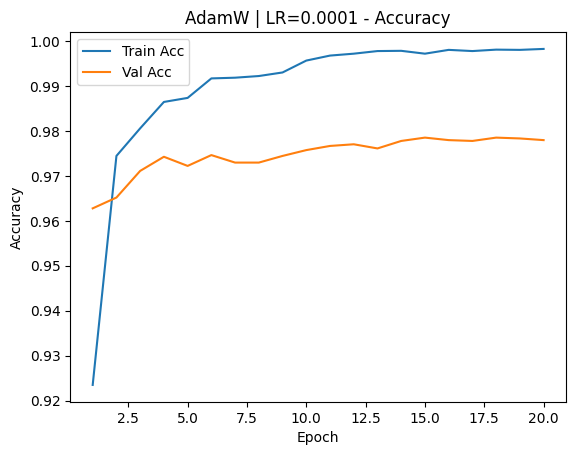

100%|██████████| 591/591 [02:35<00:00,  3.80it/s]


AdamW | LR=1e-05 | Epoch 1 | Train Acc=0.7634 | Val Acc=0.9270


100%|██████████| 591/591 [02:36<00:00,  3.77it/s]


AdamW | LR=1e-05 | Epoch 2 | Train Acc=0.9299 | Val Acc=0.9446


100%|██████████| 591/591 [02:33<00:00,  3.86it/s]


...

AdamW | LR=1e-05 | Epoch 28 | Train Acc=0.9929 | Val Acc=0.9763


100%|██████████| 591/591 [02:39<00:00,  3.70it/s]


AdamW | LR=1e-05 | Epoch 29 | Train Acc=0.9933 | Val Acc=0.9765


100%|██████████| 591/591 [02:38<00:00,  3.72it/s]


AdamW | LR=1e-05 | Epoch 30 | Train Acc=0.9925 | Val Acc=0.9765
Early stopping


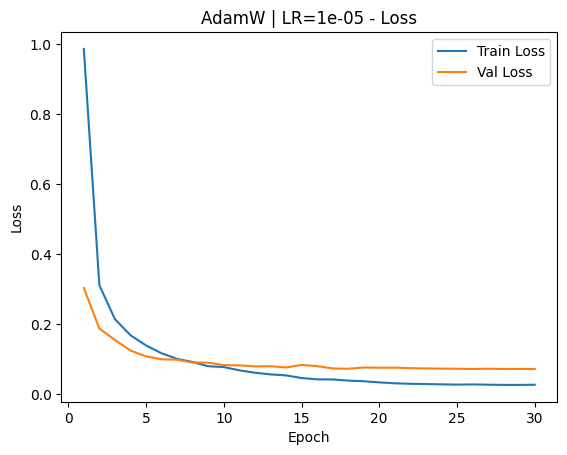

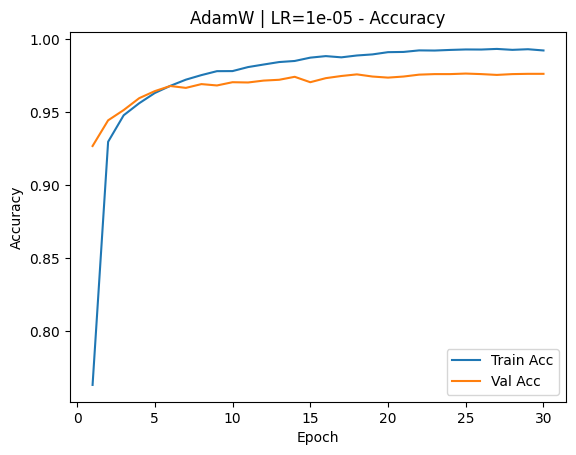


>>> BEST AdamW: LR=0.001 | Val Acc=0.9798


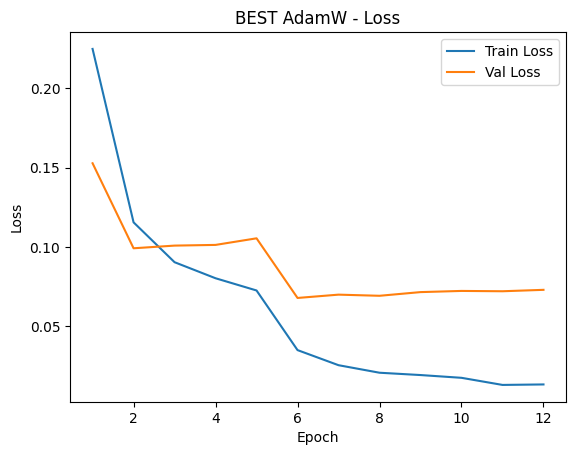

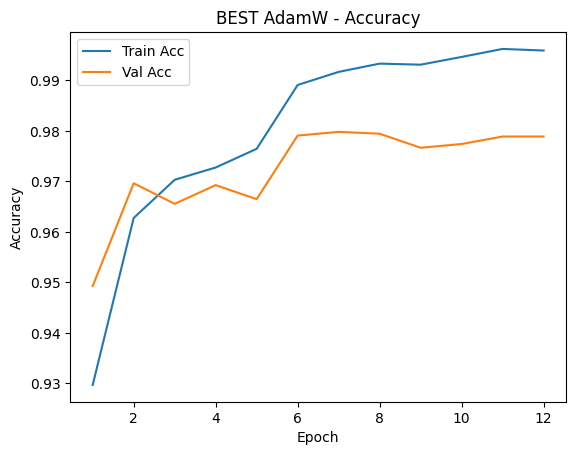


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       300
           1       0.99      0.99      0.99       300
           2       0.97      0.96      0.97       300
           3       0.96      0.98      0.97       250
           4       0.99      1.00      0.99       250
           5       0.97      0.97      0.97       200
           6       0.96      0.97      0.96       250
           7       1.00      1.00      1.00       300
           8       0.98      0.97      0.97       250
           9       1.00      1.00      1.00       300

    accuracy                           0.98      2700
   macro avg       0.98      0.98      0.98      2700
weighted avg       0.98      0.98      0.98      2700


===== CONFUSION MATRIX =====
[[292   0   0   1   0   1   6   0   0   0]
 [  0 298   1   0   0   0   0   0   1   0]
 [  0   3 288   1   0   4   3   1   0   0]
 [  0   0   0 245   1   0   0   0   4   0]
 [  

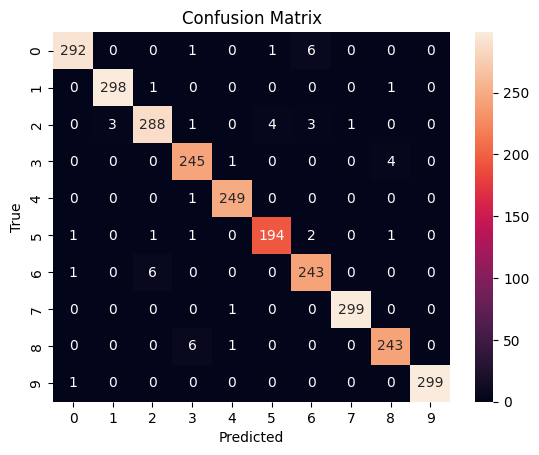

100%|██████████| 591/591 [02:34<00:00,  3.83it/s]


SGD | LR=0.001 | Epoch 1 | Train Acc=0.8761 | Val Acc=0.9396


100%|██████████| 591/591 [02:37<00:00,  3.76it/s]


SGD | LR=0.001 | Epoch 2 | Train Acc=0.9457 | Val Acc=0.9524


100%|██████████| 591/591 [02:33<00:00,  3.84it/s]


...

SGD | LR=0.001 | Epoch 20 | Train Acc=0.9837 | Val Acc=0.9730


100%|██████████| 591/591 [02:34<00:00,  3.82it/s]


SGD | LR=0.001 | Epoch 21 | Train Acc=0.9835 | Val Acc=0.9730


100%|██████████| 591/591 [02:35<00:00,  3.81it/s]


SGD | LR=0.001 | Epoch 22 | Train Acc=0.9857 | Val Acc=0.9728
Early stopping


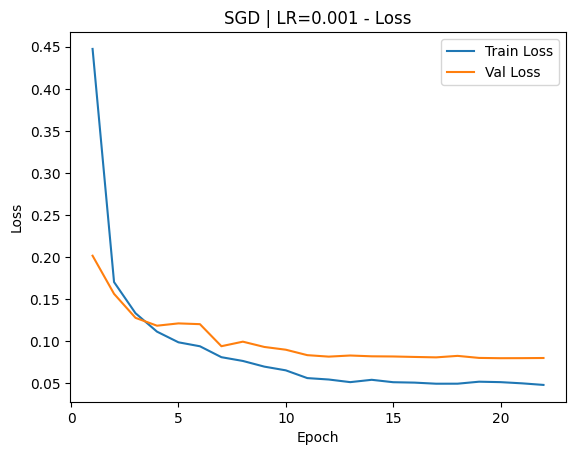

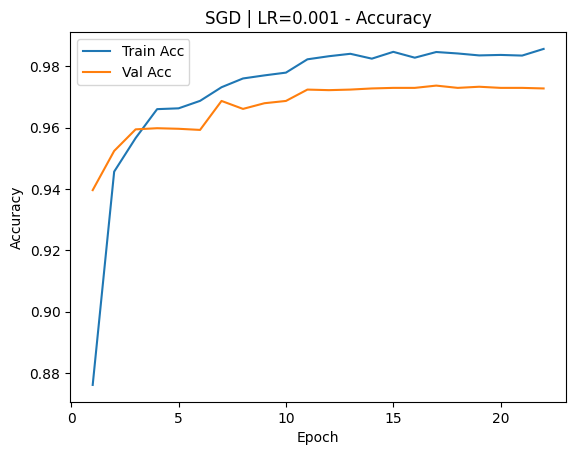

100%|██████████| 591/591 [02:44<00:00,  3.60it/s]


SGD | LR=0.0001 | Epoch 1 | Train Acc=0.6804 | Val Acc=0.8319


100%|██████████| 591/591 [03:04<00:00,  3.21it/s]


SGD | LR=0.0001 | Epoch 2 | Train Acc=0.8693 | Val Acc=0.8791


100%|██████████| 591/591 [02:39<00:00,  3.71it/s]


...

SGD | LR=0.0001 | Epoch 28 | Train Acc=0.9639 | Val Acc=0.9617


100%|██████████| 591/591 [02:50<00:00,  3.47it/s]


SGD | LR=0.0001 | Epoch 29 | Train Acc=0.9654 | Val Acc=0.9628


100%|██████████| 591/591 [03:13<00:00,  3.06it/s]


SGD | LR=0.0001 | Epoch 30 | Train Acc=0.9646 | Val Acc=0.9637


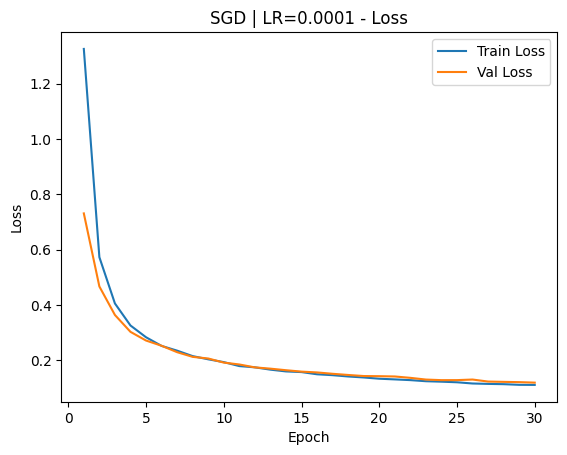

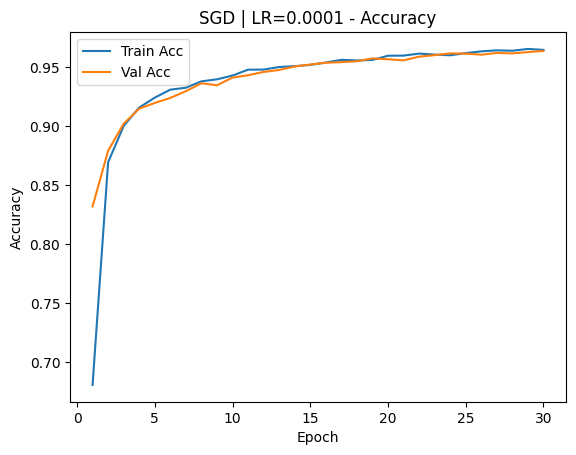

100%|██████████| 591/591 [02:37<00:00,  3.76it/s]


SGD | LR=1e-05 | Epoch 1 | Train Acc=0.3298 | Val Acc=0.4515


100%|██████████| 591/591 [02:34<00:00,  3.82it/s]


SGD | LR=1e-05 | Epoch 2 | Train Acc=0.5424 | Val Acc=0.6235


100%|██████████| 591/591 [02:34<00:00,  3.83it/s]


...

SGD | LR=1e-05 | Epoch 28 | Train Acc=0.9052 | Val Acc=0.8994


100%|██████████| 591/591 [02:33<00:00,  3.85it/s]


SGD | LR=1e-05 | Epoch 29 | Train Acc=0.9094 | Val Acc=0.8996


100%|██████████| 591/591 [02:35<00:00,  3.79it/s]


SGD | LR=1e-05 | Epoch 30 | Train Acc=0.9078 | Val Acc=0.9020


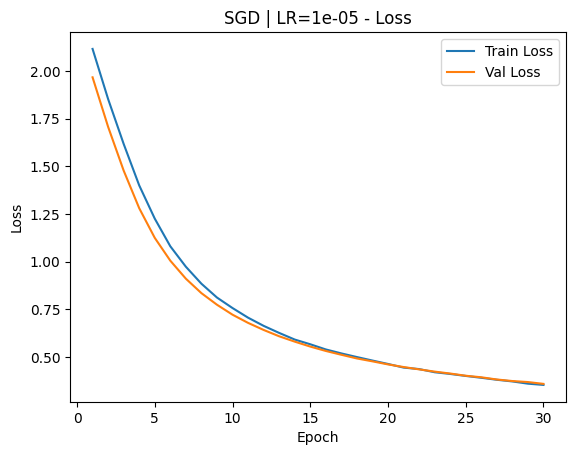

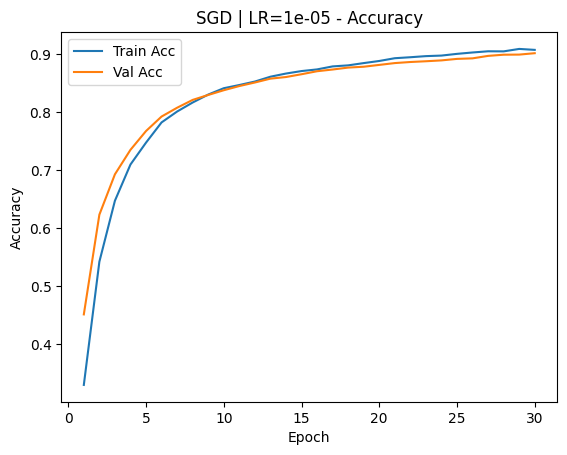


>>> BEST SGD: LR=0.001 | Val Acc=0.9737


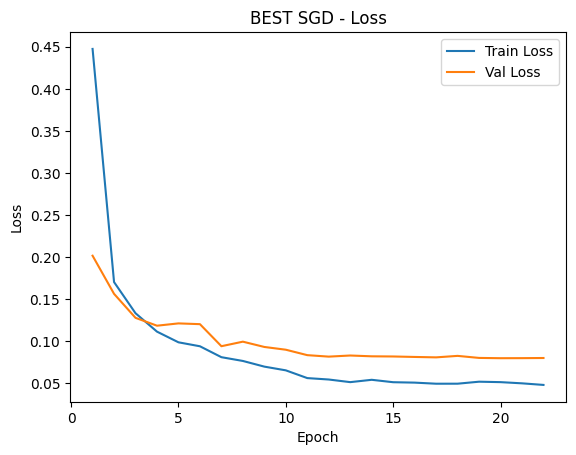

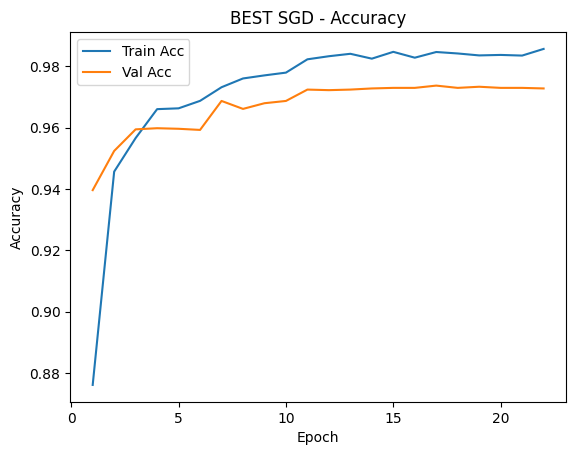


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       300
           1       0.99      0.99      0.99       300
           2       0.97      0.96      0.96       300
           3       0.96      0.96      0.96       250
           4       0.98      1.00      0.99       250
           5       0.95      0.96      0.96       200
           6       0.96      0.94      0.95       250
           7       1.00      0.99      0.99       300
           8       0.96      0.96      0.96       250
           9       1.00      0.99      0.99       300

    accuracy                           0.97      2700
   macro avg       0.97      0.97      0.97      2700
weighted avg       0.97      0.97      0.97      2700


===== CONFUSION MATRIX =====
[[292   0   0   1   0   2   4   0   1   0]
 [  0 298   1   0   0   0   0   0   1   0]
 [  0   2 288   1   0   3   5   0   0   1]
 [  1   0   0 240   1   1   0   0   7   0]
 [  

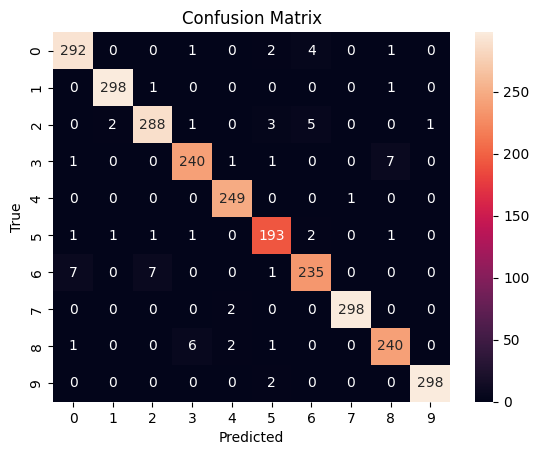

In [11]:
optimizers = ["Adam", "AdamW", "SGD"]
learning_rates = [1e-3, 1e-4, 1e-5]

results = []


global_best_acc = 0
global_best_model_weights = None
global_best_opt = None
global_best_lr = None

for opt in optimizers:

    best_acc = 0
    best_model = None
    best_lr = None
    best_history = None

    for lr in learning_rates:

        model, val_acc, history = train_model(opt, lr)

        plot_history(history, title=f"{opt} | LR={lr}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_model = model
            best_lr = lr
            best_history = history
            
        
        if val_acc > global_best_acc:
            global_best_acc = val_acc
            global_best_model_weights = copy.deepcopy(model.state_dict())
            global_best_opt = opt
            global_best_lr = lr

    print(f"\n>>> BEST {opt}: LR={best_lr} | Val Acc={best_acc:.4f}")

    plot_history(best_history, title=f"BEST {opt}")

    metrics = evaluate_model(best_model)
    metrics["Optimizer"] = opt
    metrics["Best_LR"] = best_lr

    results.append(metrics)

In [12]:
df_results = pd.DataFrame(results)

print("\n===== FINAL COMPARISON =====")
print(df_results)

best_row = df_results[
    (df_results['Optimizer'] == global_best_opt) & 
    (df_results['Best_LR'] == global_best_lr)
].iloc[0]

best_test_acc = best_row['Accuracy']

print("-" * 30)
print("Best model:")
print(f"Optimizer: {global_best_opt}")
print(f"Learning Rate: {global_best_lr}")
print(f"Validation Accuracy: {global_best_acc:.4f}")
print(f"Test Accuracy: {best_test_acc:.4f}")

save_path = 'ConvNeXt_EuroSAT_Best.pth'
torch.save(global_best_model_weights, save_path)

print(f"\nModel weights have been saved to: {save_path}")


===== FINAL COMPARISON =====
   Accuracy  Precision    Recall  F1_macro  F1_weighted Optimizer  Best_LR
0  0.985556   0.985661  0.985556  0.984898     0.985567      Adam    0.001
1  0.981481   0.981554  0.981481  0.980763     0.981488     AdamW    0.001
2  0.974444   0.974441  0.974444  0.973200     0.974422       SGD    0.001
------------------------------
Best model:
Optimizer: Adam
Learning Rate: 0.001
Validation Accuracy: 0.9811
Test Accuracy: 0.9856

Model weights have been saved to: ConvNeXt_EuroSAT_Best.pth
